Treino

In [ ]:
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import pickle

# 1. Dados
digits = fetch_ucirepo(id=80)
X, y = digits.data.features, digits.data.targets.values.ravel()

# 2. Divisão (Estratificada, 1/3 para teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, stratify=y, random_state=42)

# 3. PCA e Treino K-Means (Atividade 1 e 2)
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)

modelo = KMeans(n_clusters=10, random_state=42, n_init='auto')
modelo.fit(X_train_pca)

# 4. Guardar
pickle.dump(modelo, open("modelo.pkl", "wb"))
pickle.dump(pca, open("pca.pkl", "wb"))
pickle.dump((X_test, y_test), open("teste.pkl", "wb"))
print("Treino concluído.")

Treino concluído.


Teste

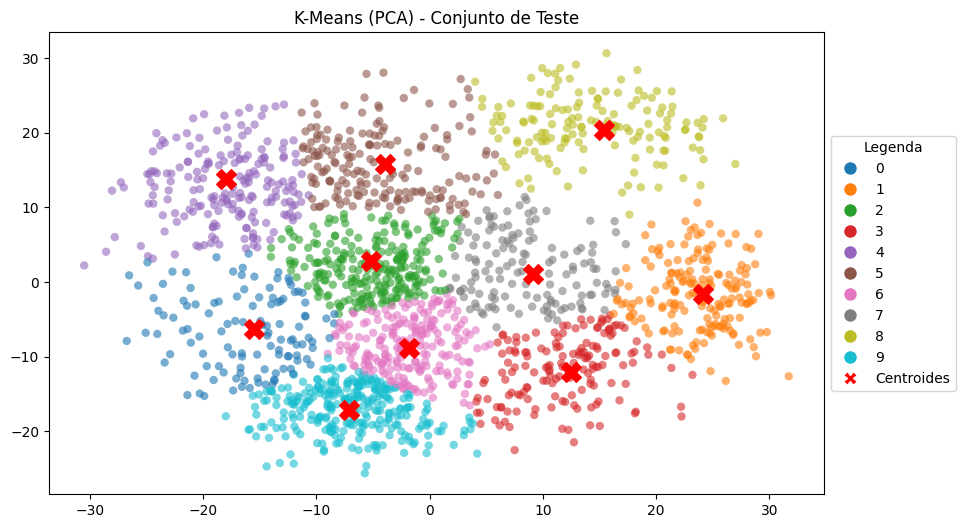

In [ ]:
import pickle
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# 1. Carregar
modelo = pickle.load(open("modelo.pkl", "rb"))
pca = pickle.load(open("pca.pkl", "rb"))
X_test, y_test = pickle.load(open("teste.pkl", "rb"))

# 2. Transformar e Prever Clusters
X_test_pca = pca.transform(X_test)
y_pred = modelo.predict(X_test_pca)
centroides = modelo.cluster_centers_

# 3. Gráfico e Centroides (Atividade 3)
cmap = plt.get_cmap('tab10', 10)
plt.figure(figsize=(10, 6))

# Nuvem de pontos dos clusters
plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_pred, cmap=cmap, alpha=0.6, edgecolors='none')

# Desenhar os Centroides
plt.scatter(centroides[:, 0], centroides[:, 1], c='red', marker='X', s=200, label='Centroides')

# Legenda dos Clusters
legend_elements = [Line2D([0], [0], marker='o', color='w', label=f"{i}",
                          markerfacecolor=cmap(i), markersize=10) for i in range(10)]
plt.legend(handles=legend_elements + [Line2D([0], [0], marker='X', color='w', markerfacecolor='red', markersize=10, label='Centroides')],
           title="Legenda", loc='center left', bbox_to_anchor=(1, 0.5))

plt.title("K-Means (PCA) - Conjunto de Teste")
plt.show()

Previsão

In [ ]:
from ucimlrepo import fetch_ucirepo
import pickle

# 1. Carregar
modelo = pickle.load(open("modelo.pkl", "rb"))
pca = pickle.load(open("pca.pkl", "rb"))

# 2. Dados
digits = fetch_ucirepo(id=80)
X, y = digits.data.features, digits.data.targets


novo = X.iloc[[12]]
novo_pca = pca.transform(novo)

# 4. Resultado
print("Previsão:", modelo.predict(novo_pca)[0])
print("Dígito Real impresso:", y.iloc[12].values[0])

Previsão: 5
Dígito Real impresso: 9
